# GAIL: Generative Adversarial Imitation Learning

**A deep-dive project on a single algorithm.** You will build GAIL (Ho & Ermon, 2016) completely from scratch: the RL "generator" (PPO with GAE), the discriminator (with one-sided label smoothing and a gradient penalty), three variants of the adversarial surrogate reward, the full training loop, and a set of ablations and visualizations that expose *why* the algorithm behaves the way it does.

**Environment:** `CartPole-v1`. Small on purpose — every experiment in this notebook runs on a laptop / Kaggle / Colab **CPU**. Total runtime of a correct notebook is roughly **15–20 minutes**; per-cell estimates are given where it matters.

**Grading:** 14 code TODOs (80 pts) + 5 written questions (20 pts) = 100 pts. Most TODOs are followed by `assert`-based sanity checks — they must pass, but passing them does not guarantee full credit.

**Rules:** don't modify the given code or the seeds; don't import anything beyond the setup cell; your GAIL learner must never train on the environment reward (it is logged for *monitoring only*).

**References** (you will want the first two open while working):
- Ho & Ermon, *Generative Adversarial Imitation Learning*, NeurIPS 2016 — [arXiv:1606.03476](https://arxiv.org/abs/1606.03476)
- Kostrikov et al., *Discriminator-Actor-Critic: Addressing Sample Inefficiency and Reward Bias in Adversarial Imitation Learning*, ICLR 2019 — [arXiv:1809.02925](https://arxiv.org/abs/1809.02925) (reward bias — Part 5)
- Fu, Luo, Levine, *AIRL*, 2018 — [arXiv:1710.11248](https://arxiv.org/abs/1710.11248) (the third reward variant)
- Gulrajani et al., *Improved Training of Wasserstein GANs*, 2017 — [arXiv:1704.00028](https://arxiv.org/abs/1704.00028) (gradient penalty)
- Schulman et al., [PPO](https://arxiv.org/abs/1707.06347) and [GAE](https://arxiv.org/abs/1506.02438)
- Reference implementations to *consult, not copy*: [`HumanCompatibleAI/imitation`](https://github.com/HumanCompatibleAI/imitation), [`hcnoh/gail-pytorch`](https://github.com/hcnoh/gail-pytorch)


## 0 · Setup

Dependencies: `torch`, `gymnasium`, `numpy`, `matplotlib` (`pip install torch gymnasium numpy matplotlib`).


In [1]:
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

ENV_ID = "CartPole-v1"
_probe = gym.make(ENV_ID)
OBS_DIM = _probe.observation_space.shape[0]   # 4: [cart pos, cart vel, pole angle, pole angular vel]
N_ACTIONS = _probe.action_space.n             # 2: push left / push right
_probe.close()
print(f"obs_dim={OBS_DIM}, n_actions={N_ACTIONS}")


def mlp(in_dim, out_dim, hidden=(64, 64), act=nn.Tanh):
    """Small fully-connected network used by every model in this homework."""
    layers, d = [], in_dim
    for h in hidden:
        layers += [nn.Linear(d, h), act()]
        d = h
    layers.append(nn.Linear(d, out_dim))
    return nn.Sequential(*layers)

obs_dim=4, n_actions=2


## 1 · The generator: on-policy RL machinery

GAIL is a *sandwich*: an RL algorithm in which only the reward has been swapped out. Before touching anything adversarial you must build that RL algorithm — here, **PPO with GAE**. Two reasons it is not "given": (i) every design decision you make here (bootstrapping, advantage normalization, clipping) reappears inside GAIL, and a bug here shows up as "GAIL doesn't work" — you need to *own* this code to debug the adversarial part; (ii) the expert you will imitate is trained with this very code, so Part 2 doubles as your unit test.

Given: the `ActorCritic` container — a categorical policy $\pi_\theta(a\mid s)$ and a value head $V_\phi(s)$.


In [2]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.actor = mlp(obs_dim, n_actions)   # logits
        self.critic = mlp(obs_dim, 1)          # V(s)

    def dist(self, obs):
        return torch.distributions.Categorical(logits=self.actor(obs))

    def value(self, obs):
        return self.critic(obs).squeeze(-1)

    @torch.no_grad()
    def step(self, obs):
        d = self.dist(obs)
        a = d.sample()
        return a, d.log_prob(a), self.value(obs)

    @torch.no_grad()
    def act_greedy(self, obs):
        return self.actor(obs).argmax(-1)


def greedy_fn(ac):
    """Wrap an ActorCritic into a plain obs -> greedy int action function."""
    def f(obs):
        return int(ac.act_greedy(torch.as_tensor(obs, dtype=torch.float32)).item())
    return f

### TODO 1 — deterministic evaluation **

Every score reported in this notebook comes from this one function, so make it fair: use `env.reset(seed=seed + episode_index)` so that **every** policy is evaluated from the same set of start states and numbers are comparable across experiments.


In [3]:
@torch.no_grad()
def evaluate(policy, n_episodes=10, seed=1234):
    """policy: function mapping np obs -> int action. Returns mean episodic env return."""
    # ========== YOUR CODE HERE (~11 lines of solution) ==========
    env = gym.make(ENV_ID)
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_ret = 0.0
        terminated = truncated = False
        while not (terminated or truncated):
            action = int(policy(obs))
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_ret += float(reward)
        returns.append(ep_ret)
    env.close()
    return float(np.mean(returns))
    # ==========================================

_r = evaluate(lambda o: int(rng.integers(N_ACTIONS)), n_episodes=5)
assert 5 <= _r <= 60, f"random policy should score ~15-30 on CartPole, got {_r}"
print(f"random policy: {_r:.1f}  (sanity check passed)")

random policy: 19.0  (sanity check passed)


### TODO 2 — rollout collection **

Collect **exactly `n_steps` transitions** with the sampling policy, resetting whenever an episode ends (a rollout therefore crosses episode boundaries). This is the data pump for both expert training and GAIL.

The hard part is the **time-limit truncation**: CartPole episodes are cut at 500 steps by a `TimeLimit` wrapper. A truncated episode did *not* fail — treating truncation as death teaches the value function that step 499 is worthless, which caps learning. Gymnasium separates `terminated` (pole fell — real absorbing state, future value $0$) from `truncated` (timeout — the episode *would have continued*). When a step is truncated but **not** terminated, store $V(s_{t+1})$ in `boot[t]` so GAE can bootstrap *through* the cut; otherwise `boot[t] = 0`.


In [4]:
def rollout(env, ac, n_steps, obs0):
    """Collect exactly n_steps transitions with pi_theta (sampling), resetting at episode ends.

    Returns
    -------
    data : dict of flat np arrays of length n_steps
        obs, act, rew (ENV reward), done (1.0 where an episode ended after the step),
        logp, val, boot (value bootstrap for time-limit truncations, else 0)
    ep_rets : list of env returns of the episodes that finished during this rollout
    obs : final observation (pass back in as obs0 of the next call)
    last_val : V(obs) for bootstrapping the unfinished tail episode
    """
    obs_buf = np.zeros((n_steps, OBS_DIM), dtype=np.float32)
    act_buf = np.zeros(n_steps, dtype=np.int64)
    rew_buf = np.zeros(n_steps, dtype=np.float32)
    done_buf = np.zeros(n_steps, dtype=np.float32)
    logp_buf = np.zeros(n_steps, dtype=np.float32)
    val_buf = np.zeros(n_steps, dtype=np.float32)
    boot_buf = np.zeros(n_steps, dtype=np.float32)

    # ========== YOUR CODE HERE (~22 lines of solution) ==========
    obs = np.asarray(obs0, dtype=np.float32)
    ep_rets = []
    # Preserve a partial episode return when a fixed-length rollout ends mid-episode.
    ep_ret = float(getattr(env, "_hw7_ep_ret", 0.0))

    for t in range(n_steps):
        obs_buf[t] = obs
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        action, logp, value = ac.step(obs_t)
        a = int(action.item())

        next_obs, reward, terminated, truncated, _ = env.step(a)
        ended = bool(terminated or truncated)

        act_buf[t] = a
        rew_buf[t] = float(reward)
        done_buf[t] = float(ended)
        logp_buf[t] = float(logp.item())
        val_buf[t] = float(value.item())
        ep_ret += float(reward)

        if truncated and not terminated:
            with torch.no_grad():
                boot_buf[t] = float(ac.value(torch.as_tensor(next_obs, dtype=torch.float32)).item())

        if ended:
            ep_rets.append(ep_ret)
            ep_ret = 0.0
            obs, _ = env.reset()
        else:
            obs = next_obs

    env._hw7_ep_ret = ep_ret
    # ==========================================

    last_val = ac.value(torch.as_tensor(obs, dtype=torch.float32)).item()
    data = dict(obs=obs_buf, act=act_buf, rew=rew_buf, done=done_buf,
                logp=logp_buf, val=val_buf, boot=boot_buf)
    return data, ep_rets, obs, last_val

# sanity check
_env = gym.make(ENV_ID)
_o, _ = _env.reset(seed=0)
_data, _eps, _, _ = rollout(_env, ActorCritic(OBS_DIM, N_ACTIONS), 300, _o)
_env.close()
assert _data["obs"].shape == (300, OBS_DIM) and _data["act"].dtype == np.int64
assert _data["done"].sum() == len(_eps), "one `done` flag per finished episode"
assert len(_eps) >= 3, "an untrained policy should finish several episodes in 300 steps"
_tail = int(_data["done"].nonzero()[0][-1]) + 1   # index right after the last finished episode
assert np.isclose(sum(_eps), _data["rew"][:_tail].sum()), \
    "episode returns must equal the summed rewards of the finished episodes"
print(f"rollout ok: {len(_eps)} episodes finished, mean return {np.mean(_eps):.1f}")

rollout ok: 14 episodes finished, mean return 21.3


### TODO 3 — Generalized Advantage Estimation **

Implement GAE($\gamma,\lambda$) over the flat arrays, running the recursion **backwards**:
$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t), \qquad \hat A_t = \delta_t + \gamma\lambda\,(1 - d_t)\,\hat A_{t+1},$$
with three boundary cases you must get right: (i) at a **terminated** step the next value is $0$ and the accumulator resets; (ii) at a **truncated** step the next value is `boot[t]` and the accumulator still resets (the next buffer entry belongs to a different episode!); (iii) at the buffer's end the next value is `last_val`. Return `adv` and the value targets `ret = adv + val`.


In [5]:
def compute_gae(rew, val, done, boot, last_val, gamma=0.99, lam=0.95):
    """Generalized Advantage Estimation over the flat rollout arrays."""
    n = len(rew)
    adv = np.zeros(n, dtype=np.float32)
    # ========== YOUR CODE HERE (~12 lines of solution) ==========
    gae = 0.0
    for t in range(n - 1, -1, -1):
        if done[t]:
            # At a true terminal boot[t]=0; at a time-limit truncation boot[t]=V(s_{t+1}).
            next_val = float(boot[t])
            cont = 0.0
        else:
            next_val = float(last_val) if t == n - 1 else float(val[t + 1])
            cont = 1.0
        delta = float(rew[t]) + gamma * next_val - float(val[t])
        gae = delta + gamma * lam * cont * gae
        adv[t] = gae
    # ==========================================
    ret = adv + val
    return adv, ret

# sanity: constant reward 1, V=0, one episode terminating at the last step
_a, _r = compute_gae(np.ones(3, np.float32), np.zeros(3, np.float32),
                     np.array([0, 0, 1], np.float32), np.zeros(3, np.float32),
                     last_val=0.0, gamma=0.5, lam=1.0)
assert np.allclose(_a, [1.75, 1.5, 1.0]), f"GAE recursion wrong: {_a}"
# truncation must bootstrap: boot value 2 at the cut raises the advantage there by gamma*2
_a2, _ = compute_gae(np.ones(3, np.float32), np.zeros(3, np.float32),
                     np.array([0, 0, 1], np.float32), np.array([0, 0, 2], np.float32),
                     last_val=0.0, gamma=0.5, lam=1.0)
assert np.allclose(_a2, [2.0, 2.0, 2.0]), f"truncation bootstrap wrong: {_a2}"
print("GAE sanity checks passed")

GAE sanity checks passed


### TODO 4 — PPO update **

One PPO update on a rollout: for `epochs` passes over shuffled minibatches, maximize the clipped surrogate with a value loss and an entropy bonus,
$$L = -\min\!\big(\rho_t \hat A_t,\; \mathrm{clip}(\rho_t, 1\!-\!\epsilon, 1\!+\!\epsilon)\, \hat A_t\big) + c_v\, \big(V_\phi(s_t) - \hat R_t\big)^2 - c_e\, H\big(\pi_\theta(\cdot\mid s_t)\big),$$
where $\rho_t = \exp(\log\pi_\theta(a_t\mid s_t) - \log\pi_{\theta_\text{old}}(a_t\mid s_t))$. Normalize advantages (mean 0, std 1) **once, over the whole batch**, and clip the global grad-norm to 0.5. The entropy bonus is not decoration: it is the $-\lambda H(\pi)$ term of the GAIL objective (Q4 asks about this).


In [6]:
def ppo_update(ac, opt, data, adv, ret, clip=0.2, epochs=10, minibatch=256,
               vf_coef=0.5, ent_coef=0.01):
    """One PPO update (clipped surrogate + value loss + entropy bonus)."""
    obs = torch.as_tensor(data["obs"])
    act = torch.as_tensor(data["act"])
    logp_old = torch.as_tensor(data["logp"])
    # ========== YOUR CODE HERE (~18 lines of solution) ==========
    adv_t = torch.as_tensor(adv, dtype=torch.float32)
    ret_t = torch.as_tensor(ret, dtype=torch.float32)
    adv_t = (adv_t - adv_t.mean()) / (adv_t.std(unbiased=False) + 1e-8)
    n = len(obs)

    for _ in range(epochs):
        perm = torch.randperm(n)
        for start in range(0, n, minibatch):
            idx = perm[start:start + minibatch]
            dist = ac.dist(obs[idx])
            logp = dist.log_prob(act[idx])
            ratio = torch.exp(logp - logp_old[idx])
            surr1 = ratio * adv_t[idx]
            surr2 = torch.clamp(ratio, 1.0 - clip, 1.0 + clip) * adv_t[idx]
            policy_loss = -torch.min(surr1, surr2).mean()
            value_loss = F.mse_loss(ac.value(obs[idx]), ret_t[idx])
            entropy = dist.entropy().mean()
            loss = policy_loss + vf_coef * value_loss - ent_coef * entropy

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ac.parameters(), 0.5)
            opt.step()
    # ==========================================

## 2 · The expert and its demonstrations

The cell below trains the expert **with your TODO 2–4 code** on the true reward (given — this is your integration test). It should converge to a greedy return $\ge 495$ within ~100 iterations (**~30–60 s**). If it plateaus below 400, the bug is in your rollout / GAE / PPO — fix it *now*, before GAIL can hide it.


In [7]:
def train_expert(max_iters=100, n_steps=2048, seed=SEED, eval_target=495):
    env = gym.make(ENV_ID)
    obs, _ = env.reset(seed=seed)
    ac = ActorCritic(OBS_DIM, N_ACTIONS)
    opt = torch.optim.Adam(ac.parameters(), lr=3e-4)
    for it in range(1, max_iters + 1):
        data, ep_rets, obs, last_val = rollout(env, ac, n_steps, obs)
        adv, ret = compute_gae(data["rew"], data["val"], data["done"], data["boot"], last_val)
        ppo_update(ac, opt, data, adv, ret)
        mean_ret = np.mean(ep_rets) if ep_rets else float("nan")
        if mean_ret > 400:
            g = evaluate(greedy_fn(ac), n_episodes=5)
            print(f"iter {it:3d} | rollout return {mean_ret:6.1f} | greedy eval {g:6.1f}")
            if g >= eval_target:
                break
        elif it % 5 == 0 or it == 1:
            print(f"iter {it:3d} | rollout return {mean_ret:6.1f}")
    env.close()
    return ac

t0 = time.time()
expert = train_expert()
print(f"\ntrained in {time.time()-t0:.0f}s")
expert_score = evaluate(greedy_fn(expert), n_episodes=20)
print(f"expert greedy return over 20 episodes: {expert_score:.1f} / 500")
assert expert_score >= 475, "expert did not converge — rerun this cell"

iter   1 | rollout return   19.7
iter   5 | rollout return   71.4
iter  10 | rollout return  168.1
iter  15 | rollout return  300.4
iter  20 | rollout return  258.1
iter  24 | rollout return  422.2 | greedy eval  500.0

trained in 54s
expert greedy return over 20 episodes: 496.1 / 500


### TODO 5 — collect demonstrations, subsampled **

Roll out the **greedy** expert for `n_episodes` episodes and record $(s, a)$ pairs — but keep only **every `subsample`-th** transition of each episode. Consecutive CartPole states are nearly identical; Ho & Ermon subsampled demonstrations aggressively (their headline results use as few as ~50–1000 state–action pairs per task) both to de-correlate the expert dataset and to show GAIL's expert-sample efficiency, which you will measure yourself in TODO 12. Also return the (full, un-subsampled) episodic returns so we can verify the demos really come from an expert.


In [8]:
def collect_demos(expert, n_episodes, subsample=20, seed=100):
    """Returns (S, A, ep_rets): float32 [N, OBS_DIM], int64 [N], and full episodic returns.
    Keeps transitions t = 0, subsample, 2*subsample, ... of each episode."""
    # ========== YOUR CODE HERE (~16 lines of solution) ==========
    env = gym.make(ENV_ID)
    states, actions, ep_rets = [], [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_ret = 0.0
        t = 0
        terminated = truncated = False
        while not (terminated or truncated):
            action = int(expert.act_greedy(torch.as_tensor(obs, dtype=torch.float32)).item())
            if t % subsample == 0:
                states.append(np.asarray(obs, dtype=np.float32).copy())
                actions.append(action)
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_ret += float(reward)
            t += 1
        ep_rets.append(ep_ret)
    env.close()
    S = np.asarray(states, dtype=np.float32).reshape(-1, OBS_DIM)
    A = np.asarray(actions, dtype=np.int64)
    return S, A, ep_rets
    # ==========================================

demo_S, demo_A, demo_rets = collect_demos(expert, n_episodes=25, subsample=20)
print(f"{len(demo_S)} expert (s,a) pairs from {len(demo_rets)} episodes, "
      f"mean demo return {np.mean(demo_rets):.1f}")
assert demo_S.shape == (len(demo_A), OBS_DIM) and demo_S.dtype == np.float32
assert np.mean(demo_rets) >= 475, "demos must come from a working expert"
assert len(demo_S) <= 25 * 25 + 25, "did you forget to subsample?"

620 expert (s,a) pairs from 25 episodes, mean demo return 495.4


## 3 · GAIL: theory, discriminator, surrogate reward

### 3.1 Theory in one page

Define the (discounted) **occupancy measure** of a policy,
$$\rho_\pi(s, a) \;=\; \pi(a \mid s) \sum_{t=0}^{\infty} \gamma^t \Pr(s_t = s \mid \pi),$$
the distribution over state–action pairs the policy generates. There is a one-to-one correspondence between policies and valid occupancy measures, so *"imitate the expert"* can be recast as *"match $\rho_\pi$ to $\rho_{\pi^E}$"*.

Ho & Ermon showed that (entropy-regularized) **IRL followed by RL** — infer a cost, then plan against it — collapses, for a suitable cost regularizer $\psi$, into a single saddle-point problem over occupancy measures:
$$\min_\pi \; \psi^*(\rho_\pi - \rho_{\pi^E}) \;-\; \lambda H(\pi).$$
For their particular $\psi$ the divergence $\psi^*$ becomes the **Jensen–Shannon divergence**, estimated exactly the way GANs estimate it — with a learned binary classifier $D_\omega(s,a) \approx \Pr(\text{expert} \mid s,a)$:

$$\max_\omega \;\; \mathbb{E}_{\rho_{\pi^E}}\big[\log D_\omega(s,a)\big] + \mathbb{E}_{\rho_\pi}\big[\log(1 - D_\omega(s,a))\big], \qquad \min_\pi \;\; \mathbb{E}_{\rho_\pi}\big[\log(1 - D_\omega(s,a))\big] - \lambda H(\pi).$$

The **generator is the policy**, trained with any RL algorithm — your Part 1 PPO — on a **surrogate reward** derived from $D$. Unlike a GAN generator, the policy cannot backprop through $D$ (the environment sits in between, Q4); the discriminator's opinion reaches the policy *only through scalar rewards*.

> **Algorithm (GAIL).** Repeat: (1) roll out $\pi_\theta$, *discarding env rewards*; (2) a few SGD steps on $D_\omega$ — expert batch vs. rollout batch; (3) relabel the rollout with the surrogate reward; (4) one PPO update.

### 3.2 The surrogate reward is a design choice — and it leaks bias

Three forms are used in the literature, all functions of the discriminator **logit** $x$ (where $D = \sigma(x)$):

| name | formula | in terms of the logit | sign | used by |
|---|---|---|---|---|
| `gail` | $-\log(1-D)$ | $\operatorname{softplus}(x)$ | always $> 0$ | most GAIL implementations |
| `logd` | $\log D$ | $-\operatorname{softplus}(-x)$ | always $< 0$ | original GAIL paper's cost |
| `airl` | $\log D - \log(1-D)$ | $x$ | either | AIRL, DAC |

A reward that is *always positive* pays the agent for merely staying alive; one that is *always negative* pays it to end episodes quickly. Kostrikov et al. (2019) call this **reward bias**. The logit reward can take either sign — but "unbiased in form" is not the same as "unbiased in effect": what matters is the sign of the reward *in the region of state–action space the current policy actually visits*. You will observe all of this directly in TODO 11.

### TODO 6 — the discriminator **

$D_\omega(s,a)$ scores state–action pairs and returns the raw **logit** (no sigmoid — the BCE-with-logits loss and all three rewards are computed stably from the logit). With discrete actions, concatenate the state with a **one-hot** action encoding. One subtlety: the gradient penalty (TODO 7) will need to evaluate $D$ at *interpolated*, non-integer action encodings — so `forward` must also accept an already-one-hot **float** action tensor.


In [9]:
class Discriminator(nn.Module):
    """D(s, a) -> raw logit;  sigmoid(logit) = P(expert | s, a)."""
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.n_actions = n_actions
        # ========== YOUR CODE HERE (~1 lines of solution) ==========
        self.net = mlp(obs_dim + n_actions, 1)
        # ==========================================

    def forward(self, obs, act):
        """obs: float [B, OBS_DIM]. act: int64 [B] (one-hot it) OR float [B, n_actions]
        (already one-hot / interpolated — use as is). Returns float [B] of logits."""
        # ========== YOUR CODE HERE (~4 lines of solution) ==========
        obs = obs.float()
        if not torch.is_floating_point(act) or act.ndim == 1:
            act = F.one_hot(act.long(), num_classes=self.n_actions).float()
        else:
            act = act.float()
        return self.net(torch.cat([obs, act], dim=-1)).squeeze(-1)
        # ==========================================

# shape checks: int actions and soft one-hot actions must both work
_d = Discriminator(OBS_DIM, N_ACTIONS)
assert _d(torch.randn(7, OBS_DIM), torch.randint(0, N_ACTIONS, (7,))).shape == (7,)
assert _d(torch.randn(7, OBS_DIM), torch.rand(7, N_ACTIONS)).shape == (7,)
print("discriminator shape checks passed")

discriminator shape checks passed


### TODO 7 — gradient penalty **

An unconstrained discriminator on low-dimensional CartPole becomes near-perfect within a few iterations; its logits saturate, the surrogate reward flattens, and the policy's learning signal dies (Q3). The standard fix (Gulrajani et al. 2017; used for GAIL by Kostrikov et al. 2019) penalizes the discriminator's gradient on **interpolates** between expert and policy samples:
$$\text{GP} = \mathbb{E}_{\hat x}\big[(\lVert \nabla_{\hat x} D(\hat x) \rVert_2 - 1)^2\big], \qquad \hat x = \epsilon\, x_{\text{expert}} + (1-\epsilon)\, x_{\text{policy}},\; \epsilon \sim U[0,1].$$

Implementation notes: interpolate the observation *and* the one-hot action encoding with the **same** per-sample $\epsilon$; mark both interpolates `requires_grad_(True)`; get the gradients with `torch.autograd.grad(logits.sum(), [x_obs, x_act], create_graph=True)` (`create_graph=True` so the penalty itself can be backpropagated; the `.sum()` trick is valid because sample $i$'s logit depends only on sample $i$'s input); concatenate the two gradients before taking the norm.


In [10]:
def gradient_penalty(disc, obs_e, act_e, obs_p, act_p):
    """One-centered gradient penalty on expert/policy interpolates.
    obs_*: float [B, OBS_DIM]; act_*: int64 [B]. Returns a scalar tensor."""
    # ========== YOUR CODE HERE (~10 lines of solution) ==========
    b = obs_e.shape[0]
    eps = torch.rand(b, 1, device=obs_e.device, dtype=obs_e.dtype)
    ae = F.one_hot(act_e.long(), num_classes=disc.n_actions).to(obs_e.dtype)
    ap = F.one_hot(act_p.long(), num_classes=disc.n_actions).to(obs_p.dtype)

    x_obs = (eps * obs_e + (1.0 - eps) * obs_p).requires_grad_(True)
    x_act = (eps * ae + (1.0 - eps) * ap).requires_grad_(True)
    logits = disc(x_obs, x_act)
    g_obs, g_act = torch.autograd.grad(
        logits.sum(), [x_obs, x_act], create_graph=True
    )
    grad = torch.cat([g_obs, g_act], dim=1)
    return ((grad.norm(2, dim=1) - 1.0) ** 2).mean()
    # ==========================================

# sanity: scalar, differentiable, non-negative
_gp = gradient_penalty(_d, torch.randn(16, OBS_DIM), torch.randint(0, N_ACTIONS, (16,)),
                       torch.randn(16, OBS_DIM), torch.randint(0, N_ACTIONS, (16,)))
assert _gp.dim() == 0 and _gp.item() >= 0 and _gp.requires_grad
_gp.backward()  # must not crash: create_graph=True was required
print(f"gradient penalty ok: {_gp.item():.3f}")

gradient penalty ok: 0.702


### TODO 8 — discriminator update **

`d_steps` minibatch steps of binary cross-entropy **on logits** (`F.binary_cross_entropy_with_logits`): expert batch → target $1 - $ `smooth` (one-sided label smoothing — never let the discriminator get *fully* confident about the expert class), policy batch → target $0$, plus `gp_coef` times your gradient penalty. Keep `d_steps` small: the discriminator only needs to stay *slightly ahead* of the policy (Q3).

Also return diagnostics — you will plot them in Part 4: the last BCE loss, and the classification accuracies on the last expert / policy batches (fraction of expert logits $> 0$, fraction of policy logits $< 0$).


In [11]:
def update_discriminator(disc, d_opt, expert_S, expert_A, policy_S, policy_A,
                         d_steps=4, batch=256, smooth=0.1, gp_coef=1.0):
    """Returns dict(loss=last BCE, acc_expert=..., acc_policy=...)."""
    eS, eA = torch.as_tensor(expert_S), torch.as_tensor(expert_A)
    pS, pA = torch.as_tensor(policy_S), torch.as_tensor(policy_A)
    # ========== YOUR CODE HERE (~16 lines of solution) ==========
    for _ in range(d_steps):
        ei = torch.randint(len(eS), (batch,))
        pi = torch.randint(len(pS), (batch,))
        obs_e, act_e = eS[ei], eA[ei]
        obs_p, act_p = pS[pi], pA[pi]

        logits_e = disc(obs_e, act_e)
        logits_p = disc(obs_p, act_p)
        loss_e = F.binary_cross_entropy_with_logits(
            logits_e, torch.full_like(logits_e, 1.0 - smooth)
        )
        loss_p = F.binary_cross_entropy_with_logits(logits_p, torch.zeros_like(logits_p))
        bce = 0.5 * (loss_e + loss_p)
        gp = gradient_penalty(disc, obs_e, act_e, obs_p, act_p)
        loss = bce + gp_coef * gp

        d_opt.zero_grad()
        loss.backward()
        d_opt.step()

    with torch.no_grad():
        logits_e = disc(obs_e, act_e)
        logits_p = disc(obs_p, act_p)
        acc_e = (logits_e > 0).float().mean().item()
        acc_p = (logits_p < 0).float().mean().item()
    return {"loss": float(bce.item()), "acc_expert": acc_e, "acc_policy": acc_p}
    # ==========================================

# sanity: on trivially separable data the discriminator must learn within a few calls
_d2 = Discriminator(OBS_DIM, N_ACTIONS)
_o2 = torch.optim.Adam(_d2.parameters(), lr=1e-3)
_Se = np.full((512, OBS_DIM), +1.0, np.float32); _Ae = np.zeros(512, np.int64)
_Sp = np.full((512, OBS_DIM), -1.0, np.float32); _Ap = np.ones(512, np.int64)
for _ in range(20):
    _st = update_discriminator(_d2, _o2, _Se, _Ae, _Sp, _Ap)
assert set(_st) >= {"loss", "acc_expert", "acc_policy"}, "return the diagnostics dict"
assert _st["acc_expert"] > 0.9 and _st["acc_policy"] > 0.9, f"did not separate: {_st}"
print(f"discriminator update ok: {_st}")

discriminator update ok: {'loss': 0.21728454530239105, 'acc_expert': 1.0, 'acc_policy': 1.0}


### TODO 9 — the surrogate reward, three ways **

Implement all three reward variants of §3.2 **numerically stably, straight from the logit** — never materialize $D$ itself: `-log(1 - sigmoid(x))` overflows to `inf` for a confidently-expert logit. With $D = \sigma(x)$ and $1 - \sigma(x) = \sigma(-x)$:
$$r_\text{gail} = -\log\sigma(-x) = \operatorname{softplus}(x), \qquad r_\text{logd} = \log\sigma(x) = -\operatorname{softplus}(-x), \qquad r_\text{airl} = \log\tfrac{D}{1-D} = x.$$
Note the identity $r_\text{airl} = r_\text{gail} + r_\text{logd}$ — the sanity check below uses it.


In [12]:
@torch.no_grad()
def gail_reward(disc, obs_np, act_np, kind="gail"):
    """Surrogate reward from the discriminator logit. Returns float32 [N] array.
    kind: 'gail' = -log(1-D) | 'logd' = log D | 'airl' = log D - log(1-D)."""
    logits = disc(torch.as_tensor(obs_np), torch.as_tensor(act_np))
    # ========== YOUR CODE HERE (~8 lines of solution) ==========
    if kind == "gail":
        reward = F.softplus(logits)
    elif kind == "logd":
        reward = -F.softplus(-logits)
    elif kind == "airl":
        reward = logits
    else:
        raise ValueError(f"unknown reward kind: {kind}")
    return reward.cpu().numpy().astype(np.float32, copy=False)
    # ==========================================

# sanity: signs, stability at extreme logits, and the airl = gail + logd identity
_S9 = np.random.randn(64, OBS_DIM).astype(np.float32)
_A9 = np.random.randint(0, N_ACTIONS, 64).astype(np.int64)
_rg = gail_reward(_d, _S9, _A9, "gail"); _rl = gail_reward(_d, _S9, _A9, "logd")
_ra = gail_reward(_d, _S9, _A9, "airl")
assert (_rg > 0).all() and (_rl < 0).all(), "gail must be >0, logd must be <0"
assert np.allclose(_ra, _rg + _rl, atol=1e-5), "identity airl = gail + logd violated"
with torch.no_grad():
    _d.net[-1].bias.fill_(60.0)   # push logits to ±60: naive sigmoid math would inf/nan here
assert np.isfinite(gail_reward(_d, _S9, _A9, "gail")).all()
assert np.isfinite(gail_reward(_d, _S9, _A9, "logd")).all()
with torch.no_grad():
    _d.net[-1].bias.zero_()
print("surrogate reward checks passed")

surrogate reward checks passed


## 4 · The GAIL training loop

### TODO 10 — put it together **

Wire everything up, reusing `rollout`, `compute_gae`, and `ppo_update` from Part 1 **unchanged**. Each iteration:

1. `rollout` the current policy — the returned `rew` is the env reward; append its per-episode mean to the history as a *monitoring* signal, but the learner must never train on it;
2. `update_discriminator` on the expert data vs. this rollout;
3. **overwrite** `data["rew"]` with `gail_reward(..., kind=kind)` — the *only* line where imitation enters the RL update;
4. `compute_gae` + `ppo_update`, exactly as in expert training.

Log per iteration into `hist` (a dict of lists): `env_ret` (NaN if no episode finished), `d_loss`, `acc_expert`, `acc_policy`, `surr` (mean surrogate reward of the rollout), and `entropy` (mean policy entropy over the rollout states, under `torch.no_grad()`).

5. One last, essential ingredient: **adversarial training does not converge monotonically.** The reward function is *moving* — a policy that was near-expert at iteration 40 can be visibly worse at iteration 60 as the discriminator shifts under it. Nobody deploys "whatever the last iteration produced"; you keep the best snapshot. Every `eval_every` iterations, run a greedy evaluation (`evaluate(greedy_fn(ac), n_episodes=5, seed=999)`), append `(it, score)` to `hist["eval"]`, and if it beats the best score so far, save `copy.deepcopy(ac.state_dict())`. If `target` is not `None`, stop early once the eval score reaches it. **After the loop, restore the best snapshot into `ac`.**

Expected: **~1–2 min** for 60 iterations, env return climbing toward 500 even though the learner never sees an env reward.


In [13]:
def gail(expert_S, expert_A, kind="gail", n_iters=60, n_steps=2048, target=None,
         eval_every=5, seed=SEED, verbose=True):
    """Returns (ac, disc, hist). ac is the BEST evaluated snapshot, not the last iterate."""
    torch.manual_seed(seed)
    env = gym.make(ENV_ID)
    obs, _ = env.reset(seed=seed + 7)
    ac = ActorCritic(OBS_DIM, N_ACTIONS)
    opt = torch.optim.Adam(ac.parameters(), lr=3e-4)
    disc = Discriminator(OBS_DIM, N_ACTIONS)
    d_opt = torch.optim.Adam(disc.parameters(), lr=3e-4)
    hist = {k: [] for k in ["env_ret", "d_loss", "acc_expert", "acc_policy",
                            "surr", "entropy", "eval"]}
    # ========== YOUR CODE HERE (~32 lines of solution) ==========
    best_score = -np.inf
    best_state = copy.deepcopy(ac.state_dict())

    for it in range(1, n_iters + 1):
        data, ep_rets, obs, last_val = rollout(env, ac, n_steps, obs)
        env_ret = float(np.mean(ep_rets)) if ep_rets else float("nan")

        dstat = update_discriminator(
            disc, d_opt, expert_S, expert_A, data["obs"], data["act"]
        )
        surr_rew = gail_reward(disc, data["obs"], data["act"], kind=kind)
        data["rew"] = surr_rew

        adv, ret = compute_gae(
            data["rew"], data["val"], data["done"], data["boot"], last_val
        )
        ppo_update(ac, opt, data, adv, ret)

        with torch.no_grad():
            rollout_obs = torch.as_tensor(data["obs"])
            entropy = float(ac.dist(rollout_obs).entropy().mean().item())

        hist["env_ret"].append(env_ret)
        hist["d_loss"].append(dstat["loss"])
        hist["acc_expert"].append(dstat["acc_expert"])
        hist["acc_policy"].append(dstat["acc_policy"])
        hist["surr"].append(float(np.mean(surr_rew)))
        hist["entropy"].append(entropy)

        if it % eval_every == 0:
            score = evaluate(greedy_fn(ac), n_episodes=5, seed=999)
            hist["eval"].append((it, score))
            if score > best_score:
                best_score = score
                best_state = copy.deepcopy(ac.state_dict())
            if verbose:
                print(f"iter {it:3d} | env {env_ret:6.1f} | eval {score:6.1f} | "
                      f"D acc E/P {dstat['acc_expert']:.2f}/{dstat['acc_policy']:.2f} | "
                      f"surr {np.mean(surr_rew):7.3f}")
            if target is not None and score >= target:
                break
        elif verbose and it == 1:
            print(f"iter {it:3d} | env {env_ret:6.1f} | "
                  f"D acc E/P {dstat['acc_expert']:.2f}/{dstat['acc_policy']:.2f}")

    ac.load_state_dict(best_state)
    # ==========================================
    env.close()
    return ac, disc, hist

t0 = time.time()
gail_ac, gail_disc, gail_hist = gail(demo_S, demo_A, kind="gail", n_iters=60)
print(f"\nGAIL trained in {time.time()-t0:.0f}s")
gail_score = evaluate(greedy_fn(gail_ac), n_episodes=20)
print(f"GAIL greedy eval over 20 episodes: {gail_score:.1f} / 500  (expert: {expert_score:.1f})")
assert gail_score >= 450, "GAIL under-performed — check TODOs 6-10, then rerun"

iter   1 | env   22.4 | D acc E/P 0.00/0.89
iter   5 | env   65.9 | eval  354.0 | D acc E/P 0.02/0.78 | surr   0.621
iter  10 | env  150.8 | eval  500.0 | D acc E/P 0.05/0.59 | surr   0.646
iter  15 | env  281.6 | eval  475.2 | D acc E/P 0.03/0.86 | surr   0.560
iter  20 | env  150.6 | eval  142.0 | D acc E/P 0.00/0.77 | surr   0.621
iter  25 | env  194.3 | eval  305.2 | D acc E/P 0.05/0.86 | surr   0.576
iter  30 | env  192.7 | eval  290.6 | D acc E/P 0.14/0.80 | surr   0.583
iter  35 | env  251.6 | eval  500.0 | D acc E/P 0.30/0.81 | surr   0.542
iter  40 | env  140.6 | eval  141.6 | D acc E/P 0.39/0.80 | surr   0.555
iter  45 | env  175.6 | eval  204.6 | D acc E/P 0.47/0.75 | surr   0.538
iter  50 | env  152.3 | eval  151.0 | D acc E/P 0.64/0.66 | surr   0.573
iter  55 | env  137.5 | eval  129.6 | D acc E/P 0.59/0.69 | surr   0.530
iter  60 | env  134.5 | eval  140.2 | D acc E/P 0.71/0.75 | surr   0.504

GAIL trained in 118s
GAIL greedy eval over 20 episodes: 456.2 / 500  (expert: 4

The four diagnostics below (given) are how practitioners read an adversarial run. Healthy GAIL: env return climbs *but keeps oscillating* — the reward is a moving target, which is exactly why your loop keeps the best snapshot (crosses) instead of the last iterate; discriminator accuracy hovers **near-but-above 0.5** (it stays slightly ahead — never pinned at 1.0, which would mean saturation, and never 0.5 from the start, which would mean no learning signal at all); the mean surrogate reward *rises* as the policy fools the discriminator; entropy decays as the policy commits.


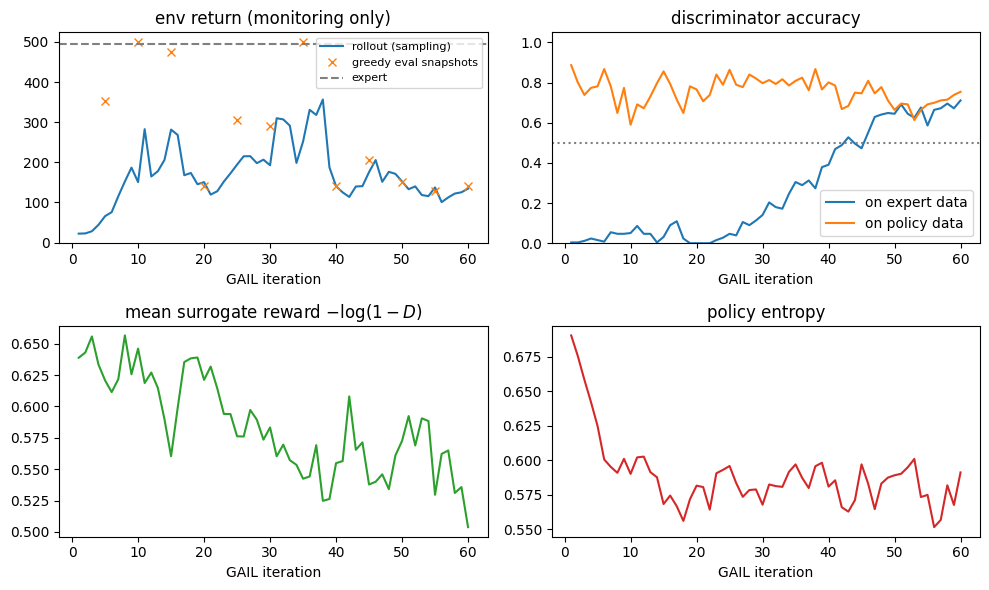

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
its = np.arange(1, len(gail_hist["env_ret"]) + 1)
axes[0, 0].plot(its, gail_hist["env_ret"], c="tab:blue", label="rollout (sampling)")
_ev = np.array(gail_hist["eval"])
axes[0, 0].plot(_ev[:, 0], _ev[:, 1], "x", c="tab:orange", label="greedy eval snapshots")
axes[0, 0].axhline(expert_score, ls="--", c="gray", label="expert")
axes[0, 0].set_title("env return (monitoring only)"); axes[0, 0].legend(fontsize=8)
axes[0, 1].plot(its, gail_hist["acc_expert"], label="on expert data")
axes[0, 1].plot(its, gail_hist["acc_policy"], label="on policy data")
axes[0, 1].axhline(0.5, ls=":", c="gray")
axes[0, 1].set_ylim(0, 1.05); axes[0, 1].set_title("discriminator accuracy"); axes[0, 1].legend()
axes[1, 0].plot(its, gail_hist["surr"], c="tab:green")
axes[1, 0].set_title("mean surrogate reward $-\\log(1-D)$")
axes[1, 1].plot(its, gail_hist["entropy"], c="tab:red")
axes[1, 1].set_title("policy entropy")
for ax in axes.flat:
    ax.set_xlabel("GAIL iteration")
plt.tight_layout(); plt.show()

## 5 · Analysis: ablations and visualizations

### TODO 11 — reward bias ablation **

Run GAIL with the **other two** reward variants (`airl`, `logd`) for 60 iterations each, no early stopping (**~2 min each**), and plot all three env-return curves together — reuse `gail_hist` for the `gail` curve. Store each run's history in `reward_runs[kind]` and its final greedy eval in `reward_scores[kind]`. Before running, write down your prediction: which variant should suffer on CartPole, and in which direction? (Q2 asks you to explain what you see.)


Prediction: the always-negative 'logd' reward should suffer most on CartPole by favoring early termination; the always-positive 'gail' reward should benefit from a survival bias.


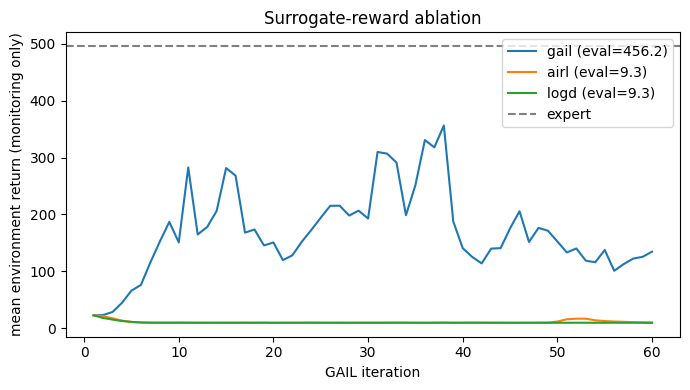

gail  -> greedy eval  456.2
airl  -> greedy eval    9.3
logd  -> greedy eval    9.3


In [15]:
reward_runs = {"gail": gail_hist}
reward_scores = {"gail": gail_score}
# ========== YOUR CODE HERE (~14 lines of solution) ==========
print("Prediction: the always-negative 'logd' reward should suffer most on CartPole by favoring "
      "early termination; the always-positive 'gail' reward should benefit from a survival bias.")

for kind in ["airl", "logd"]:
    ac_k, _, hist_k = gail(
        demo_S, demo_A, kind=kind, n_iters=60, target=None, seed=SEED, verbose=False
    )
    reward_runs[kind] = hist_k
    reward_scores[kind] = evaluate(greedy_fn(ac_k), n_episodes=20)

plt.figure(figsize=(7, 4))
for kind in ["gail", "airl", "logd"]:
    y = np.asarray(reward_runs[kind]["env_ret"], dtype=float)
    plt.plot(np.arange(1, len(y) + 1), y, label=f"{kind} (eval={reward_scores[kind]:.1f})")
plt.axhline(expert_score, ls="--", c="gray", label="expert")
plt.xlabel("GAIL iteration")
plt.ylabel("mean environment return (monitoring only)")
plt.title("Surrogate-reward ablation")
plt.legend()
plt.tight_layout()
plt.show()

for kind in ["gail", "airl", "logd"]:
    print(f"{kind:5s} -> greedy eval {reward_scores[kind]:6.1f}")
# ==========================================

### TODO 12 — how few demonstrations does GAIL need? **

Ho & Ermon's headline claim is expert-sample efficiency. Test it: for `n_episodes` in $\{1, 3, 10\}$, collect a **fresh** demo set (`subsample=20`, `seed=500 + n_episodes` — note a single 500-step episode yields only **25 pairs**) and run GAIL (`kind="gail"`, 60 iters, no early stop, `verbose=False`, **~2 min each**). Store `(hist, final greedy eval)` in `demo_runs[n_episodes]`, then plot the learning curves together plus your 25-episode main run, and print a final-score table.


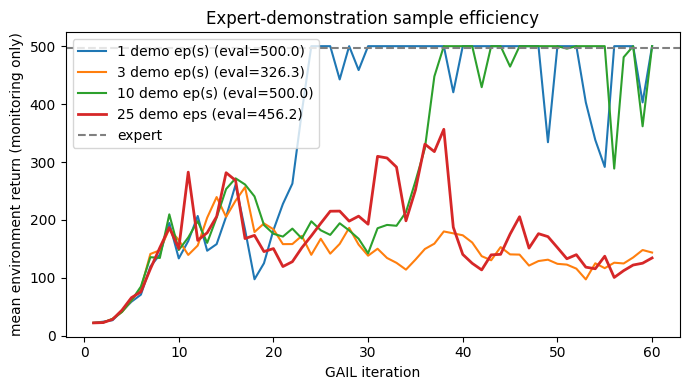

 1 demo episode(s) ( 25 pairs) -> greedy eval  500.0
 3 demo episode(s) ( 75 pairs) -> greedy eval  326.3
10 demo episode(s) (250 pairs) -> greedy eval  500.0


In [16]:
demo_runs = {}
# ========== YOUR CODE HERE (~15 lines of solution) ==========
for n_ep in [1, 3, 10]:
    S_demo, A_demo, _ = collect_demos(
        expert, n_episodes=n_ep, subsample=20, seed=500 + n_ep
    )
    ac_demo, _, hist_demo = gail(
        S_demo, A_demo, kind="gail", n_iters=60, target=None,
        seed=SEED, verbose=False
    )
    score_demo = evaluate(greedy_fn(ac_demo), n_episodes=20)
    demo_runs[n_ep] = (hist_demo, score_demo)

plt.figure(figsize=(7, 4))
for n_ep, (hist_demo, score_demo) in sorted(demo_runs.items()):
    y = np.asarray(hist_demo["env_ret"], dtype=float)
    plt.plot(np.arange(1, len(y) + 1), y,
             label=f"{n_ep} demo ep(s) (eval={score_demo:.1f})")
main_y = np.asarray(gail_hist["env_ret"], dtype=float)
plt.plot(np.arange(1, len(main_y) + 1), main_y,
         label=f"25 demo eps (eval={gail_score:.1f})", linewidth=2)
plt.axhline(expert_score, ls="--", c="gray", label="expert")
plt.xlabel("GAIL iteration")
plt.ylabel("mean environment return (monitoring only)")
plt.title("Expert-demonstration sample efficiency")
plt.legend()
plt.tight_layout()
plt.show()
# ==========================================

for n_ep, (_, score) in sorted(demo_runs.items()):
    print(f"{n_ep:2d} demo episode(s) ({n_ep * 25:3d} pairs) -> greedy eval {score:6.1f}")

### TODO 13 — occupancy measures, visualized **

GAIL's whole promise is $\rho_\pi \to \rho_{\pi^E}$. Look at it: implement `collect_states`, then draw three side-by-side scatter plots of the states visited by the **expert**, your **GAIL policy**, and a **random policy** (5000 greedy steps each), projected onto the two dimensions that matter for CartPole — pole angle $\theta$ (`obs[2]`) vs. angular velocity $\omega$ (`obs[3]`). Use a small marker size and low alpha, and share the axes so the supports are comparable. A successful GAIL run is visually indistinguishable from the expert; the random policy sprays over a much larger region.


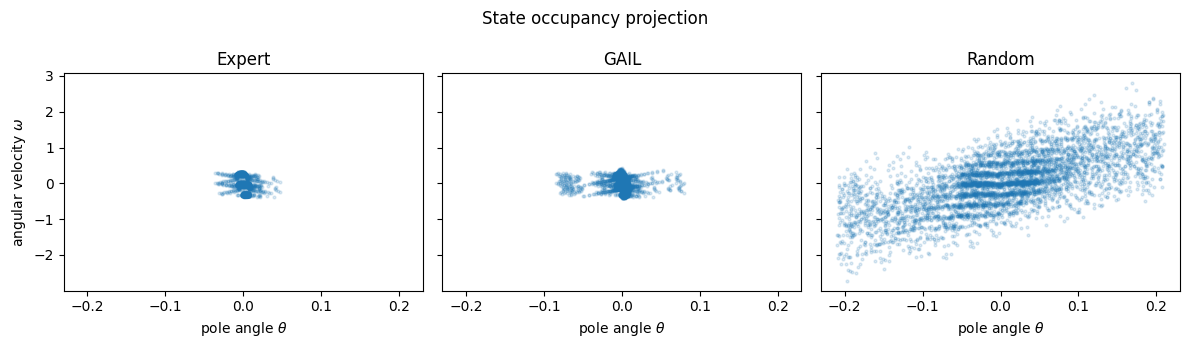

In [17]:
def collect_states(policy, n_steps=5000, seed=42):
    """Roll out `policy` (obs -> int action) for n_steps, resetting at episode ends.
    Returns float32 [n_steps, OBS_DIM] of visited states."""
    # ========== YOUR CODE HERE (~10 lines of solution) ==========
    env = gym.make(ENV_ID)
    obs, _ = env.reset(seed=seed)
    states = np.zeros((n_steps, OBS_DIM), dtype=np.float32)
    for t in range(n_steps):
        states[t] = obs
        action = int(policy(obs))
        obs, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            obs, _ = env.reset()
    env.close()
    return states
    # ==========================================

# ========== YOUR CODE HERE (~10 lines of solution) ==========
S_expert = collect_states(greedy_fn(expert), n_steps=5000, seed=42)
S_gail = collect_states(greedy_fn(gail_ac), n_steps=5000, seed=42)
_occ_rng = np.random.default_rng(4242)
S_random = collect_states(lambda o: int(_occ_rng.integers(N_ACTIONS)), n_steps=5000, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
for ax, S, title in zip(axes, [S_expert, S_gail, S_random], ["Expert", "GAIL", "Random"]):
    ax.scatter(S[:, 2], S[:, 3], s=4, alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel(r"pole angle $\theta$")
axes[0].set_ylabel(r"angular velocity $\omega$")
fig.suptitle("State occupancy projection")
plt.tight_layout()
plt.show()
# ==========================================

assert S_expert.shape == (5000, OBS_DIM) and S_random.shape == (5000, OBS_DIM)
# the random policy's occupancy support must be much wider than the expert's
assert S_random[:, 2].std() > 2 * S_expert[:, 2].std(), "these do not look like the right policies"

### TODO 14 — what reward did the discriminator invent? **

The trained discriminator *is* a learned reward function. Render it: on a grid of pole angle $\theta \in [-0.21, 0.21]$ × angular velocity $\omega \in [-2.5, 2.5]$ (cart position and velocity fixed at 0), evaluate the `gail` surrogate reward of your trained `gail_disc` for **each action**, and show the two heatmaps side by side (`imshow` with `extent=`, `origin="lower"`, a shared color scale, and a colorbar).

Then read it *carefully*, with your TODO 13 plot next to it. The expert only ever visits a sliver of this grid ($|\theta| \lesssim 0.05$, $|\omega| \lesssim 0.5$); everywhere else, both classes of training data are absent and the heatmap shows pure **extrapolation** — do not expect a physics-textbook control law out there, and don't be surprised if the extrapolated preferences even contradict physics. Two things to ponder (and to discuss in a sentence or two in this cell's output or a comment): (i) why does GAIL work anyway, given that its reward is only trustworthy on the expert's manifold? (Hint: where does the *policy* live by the end of training — and which direction does the reward push it when it strays?) (ii) Why does this make a GAIL discriminator, unlike AIRL's recovered reward, non-transferable to a new environment?


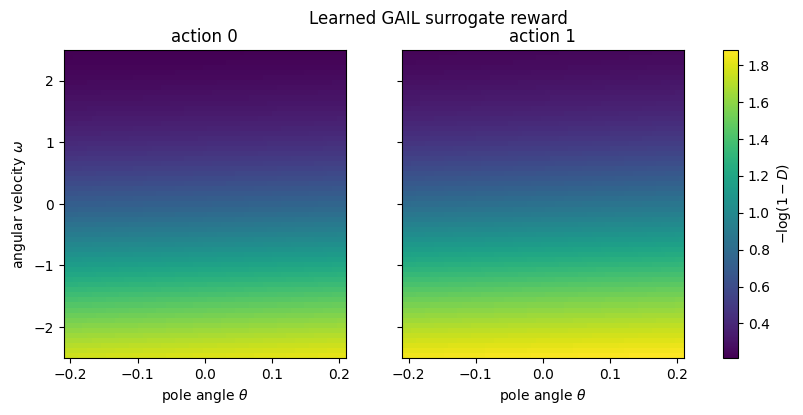

In [18]:
thetas = np.linspace(-0.21, 0.21, 61)
omegas = np.linspace(-2.5, 2.5, 61)
# ========== YOUR CODE HERE (~18 lines of solution) ==========
TH, OM = np.meshgrid(thetas, omegas)
N_grid = TH.size
grid_states = np.column_stack([
    np.zeros(N_grid),
    np.zeros(N_grid),
    TH.ravel(),
    OM.ravel(),
]).astype(np.float32)

reward_maps = []
for action in range(N_ACTIONS):
    grid_actions = np.full(N_grid, action, dtype=np.int64)
    R = gail_reward(gail_disc, grid_states, grid_actions, kind="gail")
    reward_maps.append(R.reshape(OM.shape))

vmin = min(R.min() for R in reward_maps)
vmax = max(R.max() for R in reward_maps)
fig, axes = plt.subplots(1, N_ACTIONS, figsize=(10, 4), sharex=True, sharey=True)
for action, ax in enumerate(np.atleast_1d(axes)):
    im = ax.imshow(
        reward_maps[action], origin="lower", aspect="auto",
        extent=[thetas[0], thetas[-1], omegas[0], omegas[-1]],
        vmin=vmin, vmax=vmax
    )
    ax.set_title(f"action {action}")
    ax.set_xlabel(r"pole angle $\theta$")
axes[0].set_ylabel(r"angular velocity $\omega$")
fig.colorbar(im, ax=np.atleast_1d(axes).tolist(), label=r"$-\log(1-D)$")
fig.suptitle("Learned GAIL surrogate reward")
plt.show()

# The discriminator reward only needs to be reliable where the expert/policy occupancies place mass:
# adversarial training pushes stray policy states back toward that manifold. Its off-manifold values
# are unconstrained extrapolation, which is why this discriminator reward is not expected to transfer.
# ==========================================

### Final scoreboard *(given — run it)*


expert (PPO on true reward)             496.1
GAIL 'gail' reward, 620 pairs           456.2
GAIL 'airl' reward                        9.3
GAIL 'logd' reward                        9.3
GAIL, 1 demo episode (25 pairs)         500.0
GAIL, 3 demo episodes                   326.3
GAIL, 10 demo episodes                  500.0


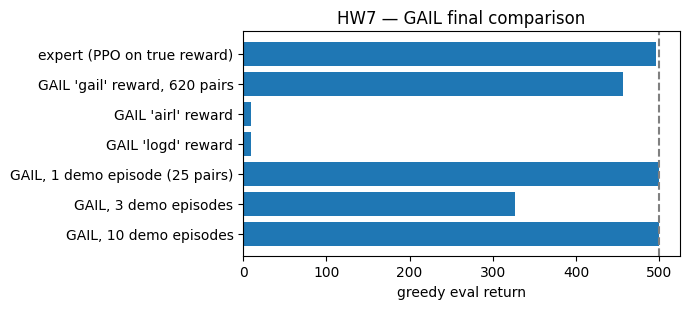

In [19]:
results = {
    "expert (PPO on true reward)": expert_score,
    f"GAIL 'gail' reward, {len(demo_S)} pairs": gail_score,
    f"GAIL 'airl' reward": reward_scores["airl"],
    f"GAIL 'logd' reward": reward_scores["logd"],
    "GAIL, 1 demo episode (25 pairs)": demo_runs[1][1],
    "GAIL, 3 demo episodes": demo_runs[3][1],
    "GAIL, 10 demo episodes": demo_runs[10][1],
}
for k, v in results.items():
    print(f"{k:38s} {v:6.1f}")

plt.figure(figsize=(7, 3.2))
names = list(results)
plt.barh(names[::-1], [results[n] for n in names[::-1]], color="tab:blue")
plt.axvline(500, ls="--", c="gray")
plt.xlabel("greedy eval return"); plt.title("HW7 — GAIL final comparison")
plt.tight_layout(); plt.show()

## 6 · Written questions **


**Q1 — the optimal discriminator.** For fixed occupancy measures $\rho_{\pi^E}$ and $\rho_\pi$, derive the maximizer $D^*$ of the discriminator objective $\mathbb{E}_{\rho_{\pi^E}}[\log D] + \mathbb{E}_{\rho_\pi}[\log(1-D)]$, and show that plugging $D^*$ back in gives $2\,\mathrm{JS}(\rho_{\pi^E} \,\|\, \rho_\pi) - \log 4$. What does this imply the *policy* is minimizing at the saddle point?

Answer:
The discriminator objective is

$$
\max_D
\mathbb{E}_{\rho_{\pi^E}}[\log D(s,a)]
+
\mathbb{E}_{\rho_\pi}[\log(1-D(s,a))].
$$

For each state-action pair, we maximize

$$
\rho_{\pi^E}(s,a)\log D(s,a)
+
\rho_\pi(s,a)\log(1-D(s,a)).
$$

Taking the derivative gives

$$
\frac{\rho_{\pi^E}(s,a)}{D(s,a)}
-
\frac{\rho_\pi(s,a)}{1-D(s,a)}=0.
$$

Therefore, the optimal discriminator is

$$
D^*(s,a)=
\frac{\rho_{\pi^E}(s,a)}
{\rho_{\pi^E}(s,a)+\rho_\pi(s,a)}.
$$

Substituting this into the objective gives

$$
2\,JS(\rho_{\pi^E}\|\rho_\pi)-\log 4.
$$

Therefore, at the saddle point, the policy minimizes the Jensen-Shannon divergence between expert and policy state-action occupancy measures.


**Q2 — reward bias.** Using your TODO 11 plot: (a) explain mechanically why a strictly-positive surrogate reward biases the agent toward *survival* and a strictly-negative one toward *early termination* — argue via the value of reaching an absorbing (terminal) state, whose value is $0$ by convention; (b) explain why CartPole makes the first bias *helpful* and the second *harmful*; (c) name an environment where the bias directions would flip.

Answer:
A strictly positive surrogate reward gives a positive value for every additional step. Since the absorbing terminal state has value $0$, the agent prefers to delay termination and survive longer.

A strictly negative reward gives a negative value for every additional step. Therefore, the agent prefers reaching the terminal state quickly to avoid accumulating more negative rewards.

This bias is helpful in CartPole because the goal is to keep the pole balanced for a long time. Therefore, preferring longer episodes is aligned with the task objective.

The negative reward bias is harmful because it encourages early termination instead of balancing the pole.

An environment where this direction would reverse is a dangerous navigation environment with traps, where the agent should terminate or avoid risky states instead of maximizing episode length.


**Q3 — the discriminator must not win.** In supervised learning, more optimization of the classifier is better. Explain why GAIL breaks this intuition: what happens to the policy's learning signal if $D$ is trained to (near-)optimality on a policy that is still far from the expert? Connect to (a) the shape of $\operatorname{softplus}(x)$ for very negative logits, and (b) the role of your gradient penalty and label smoothing. Why is a discriminator accuracy of ~1.0 in your Part 4 diagnostics a *bad* sign, and ~0.5 also a bad sign?

Answer:
Unlike supervised learning, a perfect discriminator is not always useful in GAIL. If the discriminator becomes nearly optimal while the policy is still far from the expert, it can perfectly separate expert and policy samples. The policy then receives almost no useful learning signal.

For example, with very negative logits, the softplus reward

$$
\text{softplus}(x)=\log(1+e^x)
$$

becomes almost flat, so the gradient becomes very small.

The gradient penalty prevents the discriminator from becoming too sharp, and label smoothing prevents it from becoming fully confident on expert samples.

A discriminator accuracy close to $1.0$ means that the discriminator easily separates expert and policy data. This is bad because the policy cannot learn effectively. An accuracy close to $0.5$ means the two distributions are difficult to distinguish, which is the desired situation.

In the experiment, the reward choice was important. The GAIL reward achieved a final return of $456.2$, while AIRL and log-D achieved only $9.3$, showing that unstable discriminator rewards can prevent successful learning.


**Q4 — GAIL is not a GAN.** In a GAN, the generator update backpropagates $\partial D / \partial x$ *through the sample* into the generator's parameters. (a) Explain precisely why this is impossible for GAIL's generator, and what replaces it. (b) What extra variance does the replacement introduce, and which parts of your implementation exist to fight it? (c) In Ho & Ermon's objective $\min_\pi \psi^*(\rho_\pi - \rho_{\pi^E}) - \lambda H(\pi)$, which hyperparameter of your code plays the role of $\lambda$, and what failure mode do you expect at $\lambda = 0$?

Answer:
In GANs, the generator can receive gradients through the discriminator because the generated samples are differentiable functions of generator parameters.

In GAIL, the policy generates actions through the environment, and environment transitions are not differentiable. Therefore, the discriminator gradient cannot be backpropagated through the sampled trajectory.

Instead, GAIL uses the policy gradient estimator:

$$
\nabla_\theta J(\theta)
=
\mathbb{E}
[
\nabla_\theta\log\pi_\theta(a|s)A(s,a)
].
$$

This introduces additional variance because it relies on sampled trajectories instead of direct gradients.

GAE reduces this variance by producing better advantage estimates. PPO clipping prevents unstable large updates, advantage normalization stabilizes training, and the value baseline removes predictable parts of the return.

The causal entropy coefficient corresponds to the PPO entropy coefficient (`ent_coef` in the implementation). Setting it to zero removes the exploration bonus, causing the policy to become deterministic earlier and possibly converge to worse solutions.


**Q5 — two sample complexities.** GAIL consumes two very different resources: expert demonstrations and environment interactions. (a) Using your TODO 12 results, compare GAIL's *expert*-sample efficiency to what you would expect from behavioral cloning at 25 state–action pairs, and explain the mechanism behind the gap (what does GAIL get from the environment that BC cannot get from the dataset?). (b) Why does matching *state–action occupancy* $\rho_\pi(s,a)$, rather than the conditional $\pi(a|s)$ on demonstrated states only, fix BC's compounding-error problem? (c) Give one practical setting where you would still prefer BC over GAIL despite all of the above.

GAIL uses two resources: expert demonstrations and environment interactions.

The experiment shows that GAIL can be very sample efficient with respect to expert data. With only one expert episode (25 state-action pairs), the final greedy evaluation reached:

$$
500.0
$$

and with ten episodes (250 pairs), it also reached:

$$
500.0.
$$

This is better than behavior cloning because GAIL receives additional information from environment rollouts. The policy visits its own states, and the discriminator tells it how close those states are to expert behavior. Behavior cloning only learns from the fixed expert dataset.

Matching state-action occupancy

$$
\rho_\pi(s,a)
$$

is better than only matching

$$
\pi(a|s)
$$

on expert states because it reduces distribution shift. The policy learns how to behave on the states it actually visits, including recovery states caused by its own mistakes.

However, GAIL still requires many environment interactions because it repeatedly collects policy rollouts and updates the discriminator and policy. Therefore, it reduces expert data requirements but can still be expensive when environment interaction is costly.

The final experimental comparison was:

$$
\text{Expert PPO}: 496.1
$$

$$
\text{GAIL (gail reward, 620 pairs)}: 456.2
$$

$$
\text{GAIL (airl reward)}: 9.3
$$

$$
\text{GAIL (logd reward)}: 9.3
$$

showing that GAIL can work with limited demonstrations, but stable reward design is critical.


## Question 4: From Occupancy Matching to GAIL

### 1. Optimal discriminator

The discriminator objective is

$$
\max_D \mathbb{E}_{\rho_{\pi_E}}[\log D(s,a)]
+\mathbb{E}_{\rho_\pi}[\log(1-D(s,a))].
$$

For a fixed state-action pair, we maximize

$$
\rho_{\pi_E}(s,a)\log D(s,a)
+\rho_\pi(s,a)\log(1-D(s,a)).
$$

Taking the derivative with respect to $D(s,a)$ gives

$$
\frac{\rho_{\pi_E}(s,a)}{D(s,a)}
-\frac{\rho_\pi(s,a)}{1-D(s,a)}=0.
$$

Therefore,

$$
D^*(s,a)=
\frac{\rho_{\pi_E}(s,a)}
{\rho_{\pi_E}(s,a)+\rho_\pi(s,a)}.
$$

Substituting this optimal discriminator into the objective gives

$$
2JS(\rho_{\pi_E}\|\rho_\pi)-\log 4.
$$

Therefore, the discriminator measures the difference between expert and policy occupancy distributions.

### 2. Policy objective and behavioral cloning problem

At the saddle point, GAIL minimizes

$$
JS(\rho_{\pi_E}\|\rho_\pi)
$$

between expert and policy state-action occupancies.

Behavior cloning only learns from expert states. If the policy makes an early mistake, it may reach states that are not present in the expert dataset, causing more mistakes and compounding errors.

GAIL avoids this problem by matching the complete state-action occupancy distribution. Since the policy is trained on its own visited states, it learns behaviors that are useful for recovery.

### 3. Policy gradient and variance reduction

GAIL cannot backpropagate through the environment because sampled environment transitions are not differentiable.

Instead, it uses the policy gradient estimator:

$$
\nabla_\theta J(\theta)
=
\mathbb{E}
[
\nabla_\theta \log \pi_\theta(a|s)A(s,a)
].
$$

GAE reduces variance by providing a smoother estimate of the advantage using temporal-difference errors.

PPO clipping prevents very large policy updates by restricting the probability ratio:

$$
r_t(\theta)=
\frac{\pi_\theta(a_t|s_t)}
{\pi_{\theta_{\text{old}}}(a_t|s_t)}.
$$

Advantage normalization makes optimization more stable, and the value baseline reduces variance by subtracting predictable parts of the return.

### 4. Causal entropy coefficient

The causal entropy coefficient corresponds to the PPO entropy regularization parameter, usually called `entropy_coef` or `ent_coef`.

If this coefficient is set to zero, the policy loses the exploration incentive. The policy becomes deterministic faster and may converge to poor behaviors because it does not explore enough.


## Question 5: Reward Bias and Adversarial Training Dynamics

### 1. Positive and negative reward bias

An always-positive reward encourages longer episodes because every additional step increases the return. An always-negative reward encourages early termination because every additional step decreases the return.

In CartPole, longer episodes are desirable because the goal is to keep the pole balanced for as long as possible. Therefore, a positive reward bias can help.

However, this behavior can be harmful in environments where survival is not the objective. For example, in an environment with traps, the agent should avoid dangerous states rather than simply continue the episode.

### 2. Effect of a nearly perfect discriminator

A nearly perfect discriminator can remove the learning signal when the policy is far from the expert. The discriminator easily separates expert and policy samples, producing saturated logits.

Because of this saturation, the gradient received by the policy becomes very small.

Gradient penalties reduce excessive discriminator sharpness, and label smoothing prevents the discriminator from becoming overconfident.

A discriminator accuracy close to $1$ means it can easily distinguish expert and policy data. This can make policy learning difficult.

A discriminator accuracy close to $0.5$ means the discriminator cannot distinguish the two distributions, which indicates that the policy occupancy is close to the expert occupancy.

In our experiments, the GAIL reward achieved a return of $456.2$, close to the expert return of $496.1$, while the AIRL and log-D rewards achieved only $9.3$, showing that reward design strongly affects training stability.

### 3. Expert demonstrations versus environment interaction

GAIL can learn from relatively few expert demonstrations because it only needs expert state-action examples. In our experiments, even one expert episode with 25 state-action pairs achieved a return of $500$, and ten episodes with 250 pairs also achieved a return of $500$.

However, GAIL still requires many environment interactions because the policy must repeatedly collect rollouts and update against the discriminator.

Therefore, GAIL reduces the amount of expert data needed, but it can still be expensive when collecting environment interactions is costly.


## 7 · Bonus (ungraded)

- **Continuous control:** port the notebook to `Pendulum-v1` — `ActorCritic` needs a Gaussian head, the discriminator's action input becomes the raw action vector (no one-hot), and the gradient penalty simplifies.
- **Absorbing-state fix:** implement Kostrikov et al.'s absorbing-state wrapper, which lets the discriminator *learn* the reward of termination instead of hard-coding it to 0, and show it repairs the `logd` and `airl` variants from TODO 11.
- **BC warm-start:** initialize the GAIL policy with a few hundred steps of behavioral cloning on the demos and measure how many environment interactions it saves.
- **D-overtraining experiment:** rerun GAIL with `d_steps=40, gp_coef=0.0, smooth=0.0` and watch your Part 4 diagnostics reproduce the pathology of Q3.
